In [1]:
#загружаем бибилетоки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Настройка отображения графиков
%matplotlib inline

In [3]:
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Задание 2. Знакомство с датасетом

In [4]:
print("Размер датасета:", df.shape)  # количество строк и столбцов
print("\nСтолбцы:", df.columns.tolist())  # список всех столбцов
print("\nТипы данных:")  # подпись перед выводом типов
print(df.dtypes)  # типы данных каждого столбца

Размер датасета: (891, 12)

Столбцы: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Типы данных:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


Задание 3. Анализ пассажиров



In [5]:
print("Пассажиры по классам:")  # подпись
print(df['Pclass'].value_counts().sort_index())  # количество пассажиров каждого класса

print("\nПассажиры по полу:")  # подпись
print(df['Sex'].value_counts())  # количество мужчин и женщин

bins = [0, 12, 18, 30, 50, 100]  # границы возрастных групп
labels = ['Дети (0-12)', 'Подростки (13-18)', 'Молодые (19-30)', 'Взрослые (31-50)', 'Пожилые (50+)']  # названия групп
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)  # создаём столбец с возрастными группами
print("\nВозрастные группы:")  # подпись
print(df['AgeGroup'].value_counts().sort_index())  # количество пассажиров в каждой группе

print("\nСредний возраст:", round(df['Age'].mean(), 2))  # средний возраст пассажиров
print("Медианный возраст:", df['Age'].median())  # медианный возраст пассажиров
print("Средняя стоимость билета:", round(df['Fare'].mean(), 2))  # средняя цена билета

Пассажиры по классам:
Pclass
1    216
2    184
3    491
Name: count, dtype: int64

Пассажиры по полу:
Sex
male      577
female    314
Name: count, dtype: int64

Возрастные группы:
AgeGroup
Дети (0-12)           69
Подростки (13-18)     70
Молодые (19-30)      270
Взрослые (31-50)     241
Пожилые (50+)         64
Name: count, dtype: int64

Средний возраст: 29.7
Медианный возраст: 28.0
Средняя стоимость билета: 32.2


Задание 4. Сравнение пассажиров разных классов

In [6]:
print("Средняя стоимость билета по классам:")  # подпись
print(df.groupby('Pclass')['Fare'].mean().round(2))  # средняя цена билета по классам

print("\nСредний возраст по классам:")  # подпись
print(df.groupby('Pclass')['Age'].mean().round(2))  # средний возраст по классам

print("\nПол по классам:")  # подпись
print(df.groupby(['Pclass', 'Sex']).size().unstack())  # мужчины и женщины в каждом классе

Средняя стоимость билета по классам:
Pclass
1    84.15
2    20.66
3    13.68
Name: Fare, dtype: float64

Средний возраст по классам:
Pclass
1    38.23
2    29.88
3    25.14
Name: Age, dtype: float64

Пол по классам:
Sex     female  male
Pclass              
1           94   122
2           76   108
3          144   347


Самый дорого билет

In [7]:
max_fare_row = df.loc[df['Fare'].idxmax()]  # находим строку с самым дорогим билетом
print(f"Стоимость: {max_fare_row['Fare']}")  # цена билета
print(f"Класс: {max_fare_row['Pclass']}")  # класс пассажира
print(f"Возраст: {max_fare_row['Age']}")  # возраст пассажира
print(f"Пол: {max_fare_row['Sex']}")  # пол пассажира
print(f"Выжил: {max_fare_row['Survived']}")  # факт выживания

Стоимость: 512.3292
Класс: 1
Возраст: 35.0
Пол: female
Выжил: 1


Задание 5. Анализ выживаемости

In [8]:
print("Выживаемость (0 — погиб, 1 — выжил):")  # подпись
print(df['Survived'].value_counts())  # общее количество выживших и погибших

print("\nВыживаемость по полу (доля):")  # подпись
print(df.groupby('Sex')['Survived'].mean().round(3))  # доля выживших по полу

print("\nВыживаемость по классу и полу:")  # подпись
print(df.groupby(['Pclass', 'Sex'])['Survived'].mean().round(3).unstack())  # выживаемость по классу и полу

survival_by_group = df.groupby(['Pclass', 'Sex'])['Survived'].mean()  # средняя выживаемость по группам
best = survival_by_group.idxmax()  # группа с максимальной выживаемостью
print(f"\nЛучшая группа: класс {best[0]}, пол {best[1]} — {survival_by_group.max():.3f}")  # вывод лучшей группы

Выживаемость (0 — погиб, 1 — выжил):
Survived
0    549
1    342
Name: count, dtype: int64

Выживаемость по полу (доля):
Sex
female    0.742
male      0.189
Name: Survived, dtype: float64

Выживаемость по классу и полу:
Sex     female   male
Pclass               
1        0.968  0.369
2        0.921  0.157
3        0.500  0.135

Лучшая группа: класс 1, пол female — 0.968


Задание 6. Визуализация

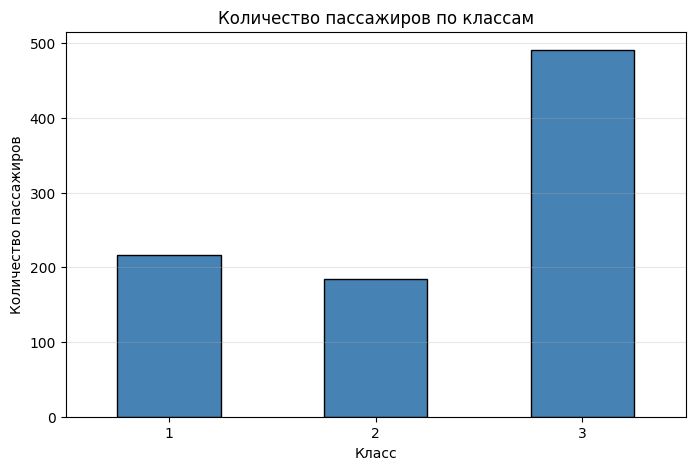

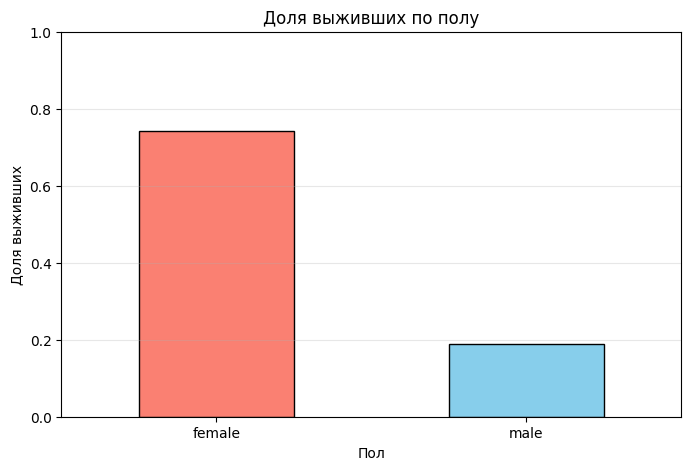

In [9]:
plt.figure(figsize=(8, 5))  # создаём график размером 8x5
df['Pclass'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')  # столбчатая диаграмма по классам
plt.title('Количество пассажиров по классам')  # заголовок графика
plt.xlabel('Класс')  # подпись оси X
plt.ylabel('Количество пассажиров')  # подпись оси Y
plt.xticks(rotation=0)  # горизонтальные подписи
plt.grid(axis='y', alpha=0.3)  # сетка по оси Y
plt.show()  # показываем график

plt.figure(figsize=(8, 5))  # создаём второй график
df.groupby('Sex')['Survived'].mean().plot(kind='bar', color=['salmon', 'skyblue'], edgecolor='black')  # выживаемость по полу
plt.title('Доля выживших по полу')  # заголовок
plt.xlabel('Пол')  # подпись оси X
plt.ylabel('Доля выживших')  # подпись оси Y
plt.xticks(rotation=0)  # горизонтальные подписи
plt.ylim(0, 1)  # диапазон оси Y от 0 до 1
plt.grid(axis='y', alpha=0.3)  # сетка по оси Y
plt.show()  # показываем график

Собственный вопрос к данным

In [10]:
df['FamilySize'] = df['SibSp'] + df['Parch']  # создаём признак "размер семьи"

print("Выживаемость по размеру семьи:")  # подпись
print(df.groupby('FamilySize')['Survived'].mean().round(3))  # доля выживших по размеру семьи
print("\nКоличество пассажиров по размеру семьи:")  # подпись
print(df['FamilySize'].value_counts().sort_index())  # количество пассажиров по размеру семьи

Выживаемость по размеру семьи:
FamilySize
0     0.304
1     0.553
2     0.578
3     0.724
4     0.200
5     0.136
6     0.333
7     0.000
10    0.000
Name: Survived, dtype: float64

Количество пассажиров по размеру семьи:
FamilySize
0     537
1     161
2     102
3      29
4      15
5      22
6      12
7       6
10      7
Name: count, dtype: int64
